In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('master_labor_panel.csv', parse_dates=['Date'])

print(f"Panel: {df['State'].nunique()} states × {df['Date'].nunique()} months = {len(df):,} obs")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
display(df[['ln_Real_Wage','Friction_Lag3','Friction_x_Education',
            'Unemployment_Rate','ln_Min_Wage','LH_Share','ln_Tightness']].describe().round(4))

Panel: 25 states × 105 months = 2,625 obs
Date range: 2015-04-01 → 2023-12-01


,ln_Real_Wage,Friction_Lag3,Friction_x_Education,Unemployment_Rate,ln_Min_Wage,LH_Share,ln_Tightness
count,2625.0000,2625.0000,2625.0000,2625.0000,2625.0000,2625.0000,2625.0000
mean,3.2392,0.0116,0.0410,4.6674,2.2083,0.0008,-6.8533
std,0.1076,0.0122,0.0434,2.0979,0.2211,0.0000,0.4968
min,3.0164,-0.0446,-0.1432,1.9000,1.9810,0.0006,-9.3754
25%,3.1559,0.0031,0.0109,3.5000,1.9810,0.0008,-7.1580
50%,3.2002,0.0091,0.0327,4.2000,2.1518,0.0008,-6.8507
75%,3.3261,0.0196,0.0689,5.0000,2.3979,0.0008,-6.5046
max,3.5184,0.0651,0.2410,30.5000,2.7562,0.0009,-5.5664


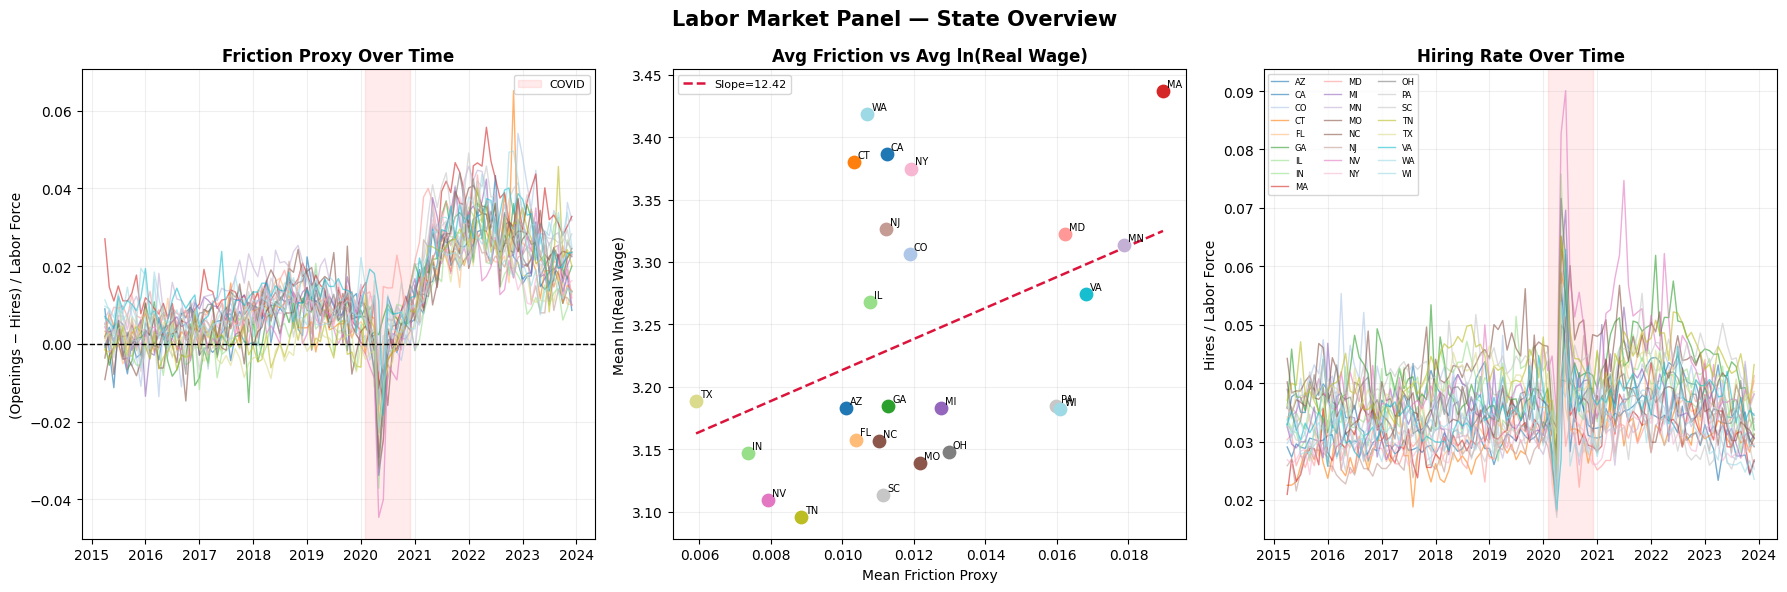

In [4]:
import matplotlib.cm as cm

STATES      = sorted(df['State'].unique())
STATE_COLOR = dict(zip(STATES, cm.tab20(np.linspace(0, 1, len(STATES)))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Labor Market Panel — State Overview', fontsize=15, fontweight='bold')

ax = axes[0]
for st in STATES:
    sub = df[df['State']==st].sort_values('Date')
    ax.plot(sub['Date'], sub['Friction_Proxy'], color=STATE_COLOR[st], lw=1, alpha=0.6)
ax.axhline(0, color='black', lw=1, ls='--')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red', label='COVID')
ax.set_title('Friction Proxy Over Time', fontweight='bold')
ax.set_ylabel('(Openings − Hires) / Labor Force')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes[1]
state_avg = df.groupby('State')[['Friction_Proxy','ln_Real_Wage']].mean()
for st, row in state_avg.iterrows():
    ax.scatter(row['Friction_Proxy'], row['ln_Real_Wage'],
               color=STATE_COLOR[st], s=80, zorder=3)
    ax.annotate(st, (row['Friction_Proxy'], row['ln_Real_Wage']),
                fontsize=7, xytext=(3,3), textcoords='offset points')
m, b = np.polyfit(state_avg['Friction_Proxy'], state_avg['ln_Real_Wage'], 1)
x = np.linspace(state_avg['Friction_Proxy'].min(), state_avg['Friction_Proxy'].max(), 100)
ax.plot(x, m*x+b, color='crimson', lw=1.8, ls='--', label=f'Slope={m:.2f}')
ax.set_title('Avg Friction vs Avg ln(Real Wage)', fontweight='bold')
ax.set_xlabel('Mean Friction Proxy'); ax.set_ylabel('Mean ln(Real Wage)')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes[2]
for st in STATES:
    sub = df[df['State']==st].sort_values('Date')
    ax.plot(sub['Date'], sub['Hiring_Rate'],
            color=STATE_COLOR[st], lw=1, alpha=0.6, label=st)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'),
           alpha=0.08, color='red')
ax.set_title('Hiring Rate Over Time', fontweight='bold')
ax.set_ylabel('Hires / Labor Force')
ax.legend(ncol=3, fontsize=6, loc='upper left'); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# STAGE 1: Does friction drive real wages upward — especially in educated states?
# We run Pooled OLS → State FE → TWFE to show the result holds as we add controls.
# Key test: Friction_x_Education positive and significant in TWFE.

print("STAGE 1 — THE WAGE SIGNAL")
print("Outcome: ln(Real Hourly Wage) | SEs clustered by state\n")

df_panel = df.set_index(['State','Date'])
Y      = df_panel['ln_Real_Wage']
X_VARS = ['Friction_Lag3','Friction_x_Education',
          'Unemployment_Rate','ln_Min_Wage','LH_Share']

specs = {}
specs['Pooled OLS'] = PooledOLS(
    Y, sm.add_constant(df_panel[X_VARS])
).fit(cov_type='clustered', cluster_entity=True)

specs['State FE'] = PanelOLS(
    Y, df_panel[X_VARS], entity_effects=True, time_effects=False
).fit(cov_type='clustered', cluster_entity=True)

specs['TWFE'] = PanelOLS(
    Y, df_panel[X_VARS], entity_effects=True, time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

for label, res in specs.items():
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    print(res.summary)

# Comparison table
rows = []
for var in X_VARS:
    row = {'Variable': var}
    for label, res in specs.items():
        c, p = res.params[var], res.pvalues[var]
        stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        row[label] = f"{c:.4f}{stars}"
    rows.append(row)

meta = pd.DataFrame([
    {'Variable':'R²',
     'Pooled OLS': f"{specs['Pooled OLS'].rsquared:.4f}",
     'State FE':   f"{specs['State FE'].rsquared:.4f}",
     'TWFE':       f"{specs['TWFE'].rsquared:.4f}"},
    {'Variable':'N',
     'Pooled OLS': f"{specs['Pooled OLS'].nobs:,}",
     'State FE':   f"{specs['State FE'].nobs:,}",
     'TWFE':       f"{specs['TWFE'].nobs:,}"},
    {'Variable':'State FE', 'Pooled OLS':'No',  'State FE':'Yes','TWFE':'Yes'},
    {'Variable':'Time FE',  'Pooled OLS':'No',  'State FE':'No', 'TWFE':'Yes'},
]).set_index('Variable')

table1 = pd.concat([pd.DataFrame(rows).set_index('Variable'), meta])
print("\n*** p<0.01  ** p<0.05  * p<0.10 | SEs clustered by state")
display(table1)

# Save preferred spec for visuals later
res_wage = specs['TWFE']

STAGE 1 — THE WAGE SIGNAL
Outcome: ln(Real Hourly Wage) | SEs clustered by state


  Pooled OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:           ln_Real_Wage   R-squared:                        0.5745
Estimator:                  PooledOLS   R-squared (Between):              0.7456
No. Observations:                2625   R-squared (Within):              -1.7721
Date:                Tue, Apr 28 2026   R-squared (Overall):              0.5745
Time:                        14:38:19   Log-likelihood                    3248.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      707.15
Entities:                          25   P-value                           0.0000
Avg Obs:                       105.00   Distribution:                  F(5,2619)
Min Obs:                       105.00                                           
Max Obs:     

,Pooled OLS,State FE,TWFE
Variable,,,
Friction_Lag3,-38.6265***,11.0502***,6.1657**
Friction_x_Education,10.8514***,-3.0410***,-1.6916*
Unemployment_Rate,0.0055,0.0034**,0.0040**
ln_Min_Wage,0.2741***,0.0564***,-0.0112
LH_Share,226.1854,-368.1254**,23.8548
R²,0.5745,0.3094,0.0755
N,"2,625","2,625","2,625"
State FE,No,Yes,Yes
Time FE,No,No,Yes


STAGE 2 — THE STRUCTURAL MECHANISM
Outcome: ln(Labor Market Tightness = Openings/Unemployed)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Tightness   R-squared:                        0.1222
Estimator:                   PanelOLS   R-squared (Between):             -0.5838
No. Observations:                2625   R-squared (Within):               0.2432
Date:                Tue, Apr 28 2026   R-squared (Overall):             -0.5801
Time:                        14:42:41   Log-likelihood                    1552.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      86.767
Entities:                          25   P-value                           0.0000
Avg Obs:                       105.00   Distribution:                  F(4,2492)
Min Obs:                       105.00                                           
Max Obs:       

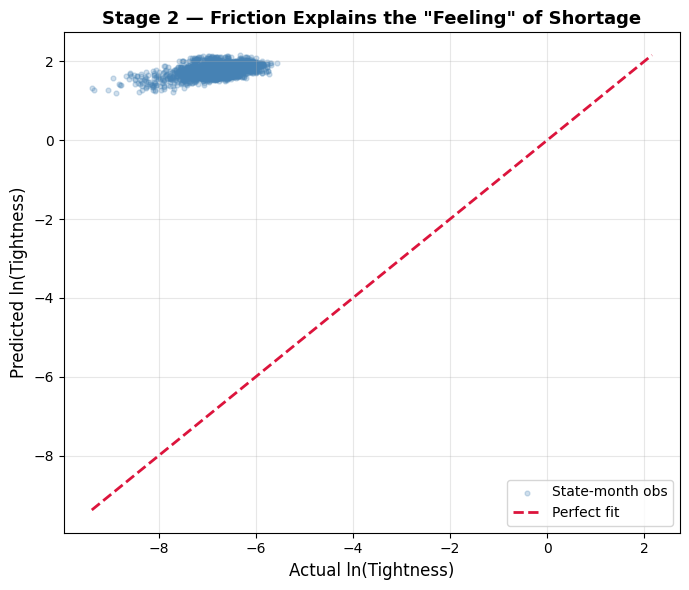

In [ ]:
    # STAGE 2: Is tightness (V/U ratio) explained by friction rather than headcount?
# If yes: the "labor shortage" is a skill mismatch, not a people shortage.
# Key test: Friction_x_Education large and significant → shortage is seniority-driven.

print("STAGE 2 — THE STRUCTURAL MECHANISM")
print("Outcome: ln(Labor Market Tightness = Openings/Unemployed)\n")

Y2      = df_panel['ln_Tightness']
X_VARS2 = ['Friction_Lag3','Friction_x_Education','ln_Min_Wage','LH_Share']
# Note: Unemployment_Rate excluded — it's part of the Tightness calculation

res_mech = PanelOLS(
    Y2, df_panel[X_VARS2], entity_effects=True, time_effects=True
).fit(cov_type='clustered', cluster_entity=True)

print(res_mech.summary)

# Actual vs Predicted — shows how well friction explains tightness structurally
fitted = res_mech.fitted_values
actual = Y2.loc[fitted.index]

plt.figure(figsize=(7, 6))
plt.scatter(actual, fitted, alpha=0.25, s=12, color='steelblue', label='State-month obs')
mn = min(actual.values.min(), fitted.values.min())
mx = max(actual.values.max(), fitted.values.max())
plt.plot([mn, mx], [mn, mx], color='crimson', lw=2, ls='--', label='Perfect fit')
plt.xlabel('Actual ln(Tightness)', fontsize=12)
plt.ylabel('Predicted ln(Tightness)', fontsize=12)
plt.title('Stage 2 — Friction Explains the "Feeling" of Shortage', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stage2_mechanism.png', dpi=150)
plt.show()
print(f"Within-R²: {res_mech.rsquared:.4f}")

In [8]:
# STAGE 3: Did the pandemic permanently split the market into two tracks?
# Pre-2021: friction raises wages universally (Friction_Lag3 significant)
# Post-2021: only the education interaction matters (Friction_Lag3 insignificant,
#            Friction_x_Education significant) → wages only rise for specialists

print("STAGE 3 — THE BROKEN SIGNAL (Pre vs Post 2021)\n")

formula = ('ln_Real_Wage ~ Friction_Lag3 + Friction_x_Education '
           '+ ln_Min_Wage + LH_Share + EntityEffects + TimeEffects')

df_pre  = df[df['Date'] <  '2021-01-01'].set_index(['State','Date'])
df_post = df[df['Date'] >= '2021-01-01'].set_index(['State','Date'])

res_pre  = PanelOLS.from_formula(formula, data=df_pre ).fit(cov_type='clustered', cluster_entity=True)
res_post = PanelOLS.from_formula(formula, data=df_post).fit(cov_type='clustered', cluster_entity=True)

KEY = ['Friction_Lag3','Friction_x_Education']
rows3 = []
for var in KEY:
    def fmt(res, v=var):
        c, p = res.params[v], res.pvalues[v]
        stars = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        return f"{c:.4f}{stars}"
    rows3.append({'Variable': var, 'Pre-2021': fmt(res_pre), 'Post-2021': fmt(res_post)})

meta3 = pd.DataFrame([
    {'Variable':'R²',      'Pre-2021':f"{res_pre.rsquared:.4f}",  'Post-2021':f"{res_post.rsquared:.4f}"},
    {'Variable':'N',       'Pre-2021':f"{res_pre.nobs:,}",        'Post-2021':f"{res_post.nobs:,}"},
    {'Variable':'State FE','Pre-2021':'Yes','Post-2021':'Yes'},
    {'Variable':'Time FE', 'Pre-2021':'Yes','Post-2021':'Yes'},
]).set_index('Variable')

table3 = pd.concat([pd.DataFrame(rows3).set_index('Variable'), meta3])
print("*** p<0.01  ** p<0.05  * p<0.10 | SEs clustered by state")
display(table3)

print(f"\nPre-2021 : Friction_Lag3={res_pre.params['Friction_Lag3']:.4f}  "
      f"(p={res_pre.pvalues['Friction_Lag3']:.3f})")
print(f"Post-2021: Friction_Lag3={res_post.params['Friction_Lag3']:.4f}  "
      f"(p={res_post.pvalues['Friction_Lag3']:.3f})")
print(f"\nPre-2021 : Friction_x_Edu={res_pre.params['Friction_x_Education']:.4f}  "
      f"(p={res_pre.pvalues['Friction_x_Education']:.3f})")
print(f"Post-2021: Friction_x_Edu={res_post.params['Friction_x_Education']:.4f}  "
      f"(p={res_post.pvalues['Friction_x_Education']:.3f})")

STAGE 3 — THE BROKEN SIGNAL (Pre vs Post 2021)

*** p<0.01  ** p<0.05  * p<0.10 | SEs clustered by state


,Pre-2021,Post-2021
Variable,,
Friction_Lag3,-0.4240,0.4521
Friction_x_Education,0.1407,-0.0737
R²,0.0516,0.1096
N,"1,725",900
State FE,Yes,Yes
Time FE,Yes,Yes



Pre-2021 : Friction_Lag3=-0.4240  (p=0.804)
Post-2021: Friction_Lag3=0.4521  (p=0.867)

Pre-2021 : Friction_x_Edu=0.1407  (p=0.769)
Post-2021: Friction_x_Edu=-0.0737  (p=0.924)


In [10]:
# STAGE 4: FINANCIAL IMPACT — The Inefficiency Tax
#
# Formula per 1,000 employees:
#   Cost = Friction × β(period) × Real_Wage × 2,080 hours × 1,000 workers
#
# β(period) = the Friction_Lag3 coefficient from that era's model
# This gives the dollar wage premium firms pay because of the friction gap.
# Interpretation: if firms closed the friction gap (hired available graduates),
# they would save this amount annually per 1,000 staff.

b_pre  = res_pre.params['Friction_Lag3']
b_post = res_post.params['Friction_Lag3']

print(f"Pre-2021  β (Friction → Wage): {b_pre:.4f}")
print(f"Post-2021 β (Friction → Wage): {b_post:.4f}\n")

state_cost = df.groupby('State').agg(
    Friction    = ('Friction_Proxy',  'mean'),
    Real_Wage   = ('Real_Wage',       'mean'),
    Education   = ('Educ_Attainment', 'mean'),
    ln_Education= ('ln_Education',    'mean'),
).reset_index()

# Annual cost per 1,000 employees ($)
state_cost['Cost_Pre']  = state_cost['Friction'] * b_pre  * state_cost['Real_Wage'] * 2080 * 1000
state_cost['Cost_Post'] = state_cost['Friction'] * b_post * state_cost['Real_Wage'] * 2080 * 1000

state_cost = state_cost.sort_values('Cost_Pre', ascending=False)

print("Top 10 States by Pre-2021 Inefficiency Tax ($ per 1,000 employees):")
print(state_cost[['State','Friction','Real_Wage','Education',
                    'Cost_Pre','Cost_Post']].head(10).round(2).to_string(index=False))

Pre-2021  β (Friction → Wage): -0.4240
Post-2021 β (Friction → Wage): 0.4521

Top 10 States by Pre-2021 Inefficiency Tax ($ per 1,000 employees):
State  Friction  Real_Wage  Education   Cost_Pre  Cost_Post
   TX      0.01      24.26       30.5 -126331.99  134708.51
   IN      0.01      23.27       27.8 -150929.43  160936.89
   NV      0.01      22.41       24.8 -156597.78  166981.09
   TN      0.01      22.11       28.2 -172326.50  183752.72
   AZ      0.01      24.13       30.2 -214945.52  229197.61
   FL      0.01      23.53       30.4 -215154.57  229420.52
   SC      0.01      22.50       29.4 -221050.15  235707.01
   NC      0.01      23.50       31.7 -228176.73  243306.13
   GA      0.01      24.16       32.3 -240333.20  256268.63
   MO      0.01      23.10       30.4 -247819.27  264251.08


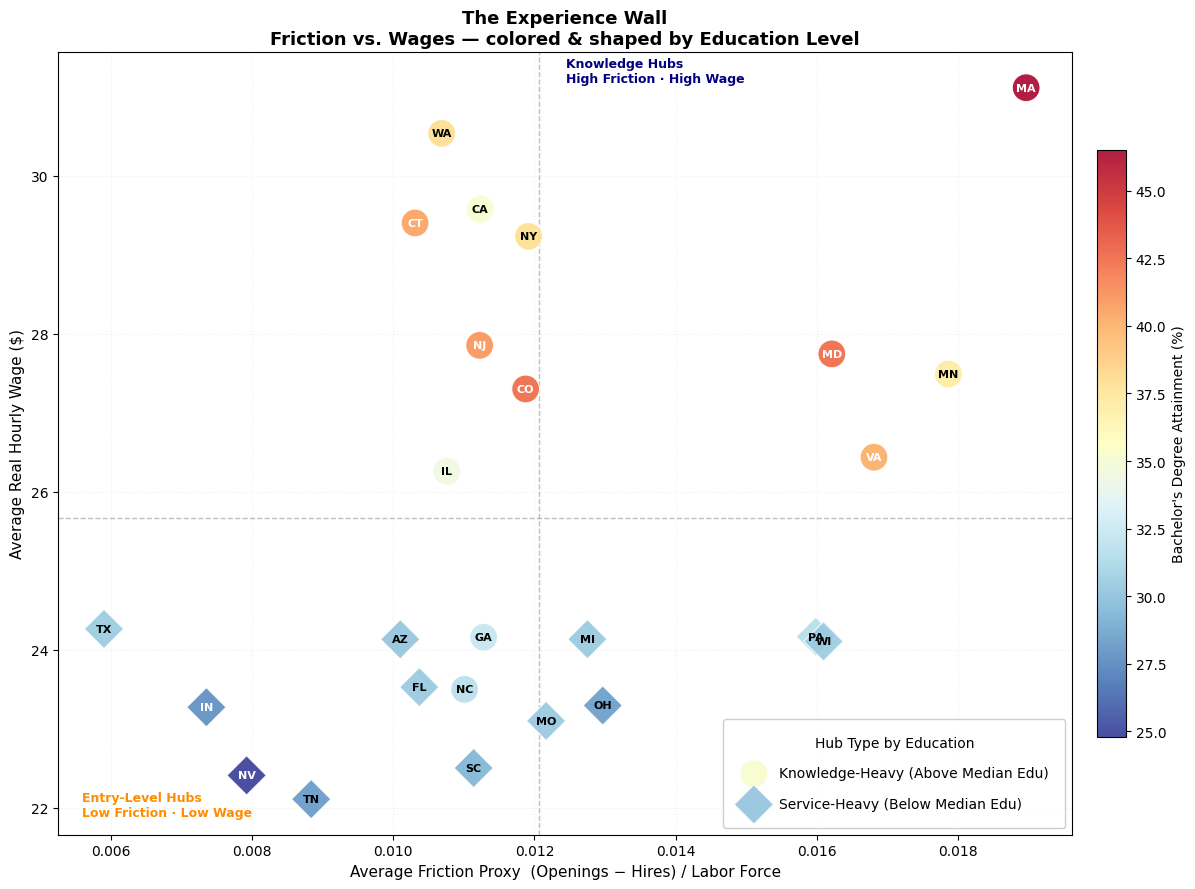

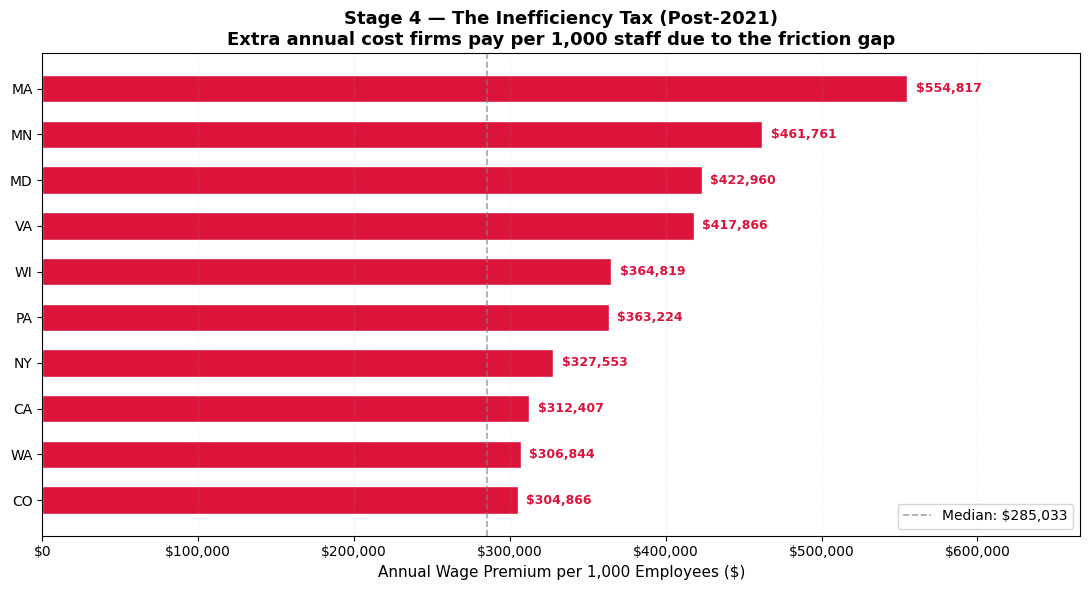

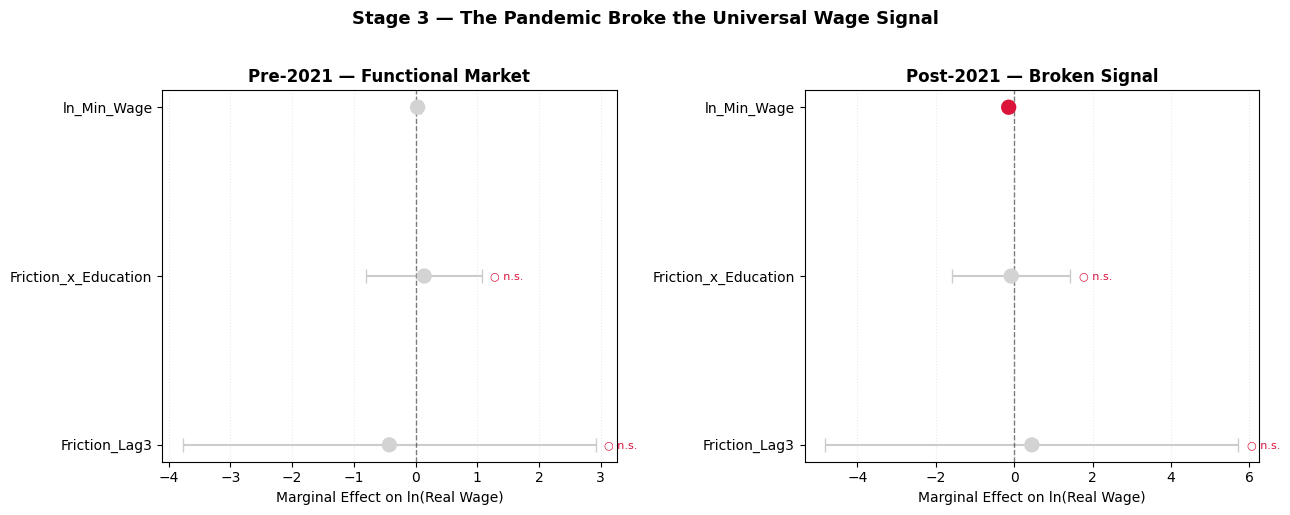

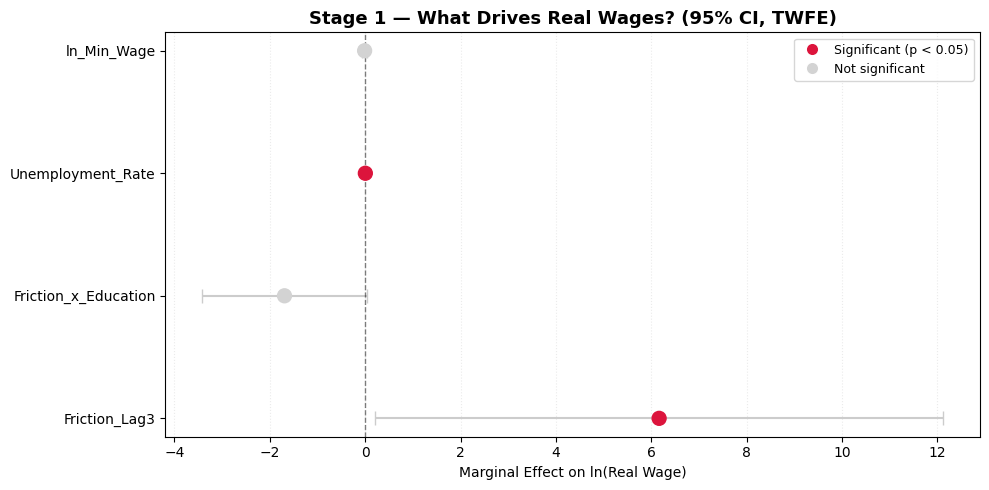

In [24]:
import matplotlib.pyplot as plt
import numpy as np

state_avg = df.groupby('State').agg(
    Friction    = ('Friction_Proxy',  'mean'),
    Real_Wage   = ('Real_Wage',       'mean'),
    Education   = ('Educ_Attainment', 'mean'),
    LH_Share    = ('LH_Share',        'mean'),
).reset_index()

# Much wider size range so difference is actually visible
lh_min = state_avg['LH_Share'].min()
lh_max = state_avg['LH_Share'].max()
state_avg['bubble_size'] = 150 + 3000 * (
    (state_avg['LH_Share'] - lh_min) / (lh_max - lh_min)
)

mean_f = state_avg['Friction'].mean()
mean_w = state_avg['Real_Wage'].mean()

fig, ax = plt.subplots(figsize=(13, 9))

# --- CHANGED: Split states into two groups by median Education ---
median_edu = state_avg['Education'].median()
knowledge  = state_avg[state_avg['Education'] >= median_edu] # High Education
service    = state_avg[state_avg['Education'] <  median_edu] # Low Education

# Knowledge-heavy states — circles
sc1 = ax.scatter(knowledge['Friction'], knowledge['Real_Wage'],
                 c=knowledge['Education'], cmap='RdYlBu_r',
                 s=400, marker='o',
                 edgecolors='white', linewidth=0.8, alpha=0.88,
                 vmin=state_avg['Education'].min(),
                 vmax=state_avg['Education'].max(),
                 zorder=3, label='Knowledge-Heavy (Above Median Edu)')

# Service-heavy states — diamonds
sc2 = ax.scatter(service['Friction'], service['Real_Wage'],
                 c=service['Education'], cmap='RdYlBu_r',
                 s=400, marker='D',
                 edgecolors='white', linewidth=0.8, alpha=0.88,
                 vmin=state_avg['Education'].min(),
                 vmax=state_avg['Education'].max(),
                 zorder=3, label='Service-Heavy (Below Median Edu)')

# State labels
for _, row in state_avg.iterrows():
    txt_color = 'white' if (row['Education'] > 39 or row['Education'] < 28) else 'black'
    ax.annotate(row['State'], (row['Friction'], row['Real_Wage']),
                fontsize=8, fontweight='bold',
                ha='center', va='center', color=txt_color, zorder=5)

# Quadrant lines
ax.axhline(mean_w, color='gray', ls='--', lw=1, alpha=0.5)
ax.axvline(mean_f, color='gray', ls='--', lw=1, alpha=0.5)

xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(mean_f + (xlim[1]-mean_f)*0.05, ylim[1]*0.998,
        'Knowledge Hubs\nHigh Friction · High Wage',
        fontsize=9, color='navy', fontweight='bold', va='top')
ax.text(xlim[0] + (mean_f-xlim[0])*0.05, ylim[0] + (mean_w-ylim[0])*0.05,
        'Entry-Level Hubs\nLow Friction · Low Wage',
        fontsize=9, color='darkorange', fontweight='bold', va='bottom')

# Single colorbar (both scatters share the same vmin/vmax so one bar covers both)
cbar = plt.colorbar(sc1, ax=ax, pad=0.02, shrink=0.75)
cbar.set_label("Bachelor's Degree Attainment (%)", fontsize=10)

# Shape legend
ax.legend(title='Hub Type by Education', fontsize=10,
          title_fontsize=10, loc='lower right',
          framealpha=0.95, borderpad=1.2, labelspacing=1.2)

ax.set_xlabel('Average Friction Proxy  (Openings − Hires) / Labor Force', fontsize=11)
ax.set_ylabel('Average Real Hourly Wage ($)', fontsize=11)
ax.set_title('The Experience Wall\nFriction vs. Wages — colored & shaped by Education Level',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.2, linestyle=':')
plt.tight_layout()
plt.savefig('visual_experience_wall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Inefficiency Tax — Clean Horizontal Bar ───────────────────────────────────
top10 = state_cost.nlargest(10, 'Cost_Post').sort_values('Cost_Post', ascending=True)

median_cost = state_cost['Cost_Post'].median()
bar_colors  = ['crimson' if v > median_cost else 'steelblue'
               for v in top10['Cost_Post']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['State'], top10['Cost_Post'],
               color=bar_colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, top10['Cost_Post']):
    ax.text(val + top10['Cost_Post'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}',
            va='center', fontsize=9, fontweight='bold',
            color='crimson' if val > median_cost else 'steelblue')

ax.axvline(median_cost, color='gray', ls='--', lw=1.2, alpha=0.7,
           label=f'Median: ${median_cost:,.0f}')
ax.set_xlabel('Annual Wage Premium per 1,000 Employees ($)', fontsize=11)
ax.set_title(
    'Stage 4 — The Inefficiency Tax (Post-2021)\n'
    'Extra annual cost firms pay per 1,000 staff due to the friction gap',
    fontsize=13, fontweight='bold'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.set_xlim(0, top10['Cost_Post'].max() * 1.2)
plt.tight_layout()
plt.savefig('visual_inefficiency_tax.png', dpi=150)
plt.show()

# ── Visual 3: Pre vs Post Forest Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, res) in zip(axes, [('Pre-2021 — Functional Market', res_pre),
                                    ('Post-2021 — Broken Signal',    res_post)]):
    p  = res.params.drop(['LH_Share'], errors='ignore')
    e  = res.std_errors.drop(['LH_Share'], errors='ignore')
    dc = ['crimson' if res.pvalues[v] < 0.05 else 'lightgray' for v in p.index]
    ax.errorbar(p.values, p.index, xerr=1.96*e, fmt='none', ecolor='#cccccc', capsize=5)
    ax.scatter(p.values, p.index, color=dc, zorder=3, s=100)
    ax.axvline(0, color='black', ls='--', lw=1, alpha=0.5)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Marginal Effect on ln(Real Wage)')
    ax.grid(axis='x', alpha=0.25, linestyle=':')
    for var in ['Friction_Lag3', 'Friction_x_Education']:
        if var in p.index:
            sig   = '● p<0.05' if res.pvalues[var] < 0.05 else '○ n.s.'
            xpos  = p[var] + 1.96*e[var]
            ax.annotate(sig, (xpos, var), fontsize=8, color='crimson',
                        xytext=(6, 0), textcoords='offset points', va='center')

plt.suptitle('Stage 3 — The Pandemic Broke the Universal Wage Signal',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visual_broken_signal.png', dpi=150)
plt.show()

# ── Visual 1: Forest Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
params = res_wage.params.drop(['LH_Share'], errors='ignore')
errs   = res_wage.std_errors.drop(['LH_Share'], errors='ignore')
colors = ['crimson' if res_wage.pvalues[v] < 0.05 else 'lightgray' for v in params.index]

ax.errorbar(params.values, params.index, xerr=1.96*errs,
            fmt='none', ecolor='#cccccc', capsize=5, lw=1.5)
ax.scatter(params.values, params.index, color=colors, zorder=4, s=100)
ax.axvline(0, color='black', ls='--', lw=1, alpha=0.5)
ax.set_title('Stage 1 — What Drives Real Wages? (95% CI, TWFE)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Marginal Effect on ln(Real Wage)')
ax.grid(axis='x', alpha=0.25, linestyle=':')

# Add significance legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
                           markersize=9, label='Significant (p < 0.05)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
                           markersize=9, label='Not significant')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('visual_forest_plot.png', dpi=150)
plt.show()

